# Tutorial 5.1: MAGPIE Registration and Preparation of SMA

This tutorial prepares human Parkinson's disease (PD) striatum data from the [Spatial Multimodal Analysis (SMA) study](https://doi.org/10.1038/s41587-023-01937-y) for PRISM. SMA profiles Visium RNA and MALDI-MSI metabolites on the same tissue section, but their native coordinate systems and resolutions do not define one-to-one spot pairs. Download the underlying SMA Visium RNA and MALDI-MSI measurements from the [RNA](https://doi.org/10.17044/scilifelab.22778920) and [MSI](https://doi.org/10.17044/scilifelab.22770161) SciLifeLab Data Delivery System records, respectively, then assemble the source-compatible `{TAG}_MSI.h5ad` input from the downloaded MSI intensity and coordinate files.

[MAGPIE](https://doi.org/10.1038/s41467-025-68003-w) provides the landmark-based co-registration used here. This repository supplies the A1, B1 and C1 `landmarks_noHE.csv` files selected with MAGPIE's [interactive landmark-selection tool](https://core-bioinformatics.github.io/magpie/shiny-app/shiny-app.html); its [official code](https://github.com/Core-Bioinformatics/magpie) supports landmark selection for new samples. These files contain coordinate pairs only, not molecular measurements, and place MSI coordinates in the Visium reference frame before one-to-one RNA-MSI matching. The tutorial defaults to the Cd3 section (`C1`) and can process Cd1 (`A1`) or Cd2 (`B1`) by changing only `TAG`.


## Workflow

1. Apply the affine transform estimated from MAGPIE landmarks to MSI pixel coordinates.
2. Read Visium RNA, add brain-region and dopamine annotations, and create the section-specific `new_label`.
3. Retain unique RNA-MSI matches within the C1 distance threshold and write a full RNA-indexed MSI object with zero-filled unregistered locations.
4. Annotate the SMA paper metabolites while retaining each original m/z in `var["mz_original"]`.


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import PRISM
from PRISM import (annotate_sma_paper_metabolites, apply_magpie_landmarks_to_msi, build_aligned_msi,
                   build_full_msi_with_missing, greedy_spatial_matching, plot_magpie_alignment_preview,
                   plot_matching_summary_bar, plot_spatial_overlay, prepare_sma_rna, sma_label_table,
                   spatial_mapping_table, write_sma_h5ad)


In [2]:
# Set to "A1" or "B1" to prepare the other SMA sections.
TAG = "C1"  
DATA_ROOT = Path("Datasets") / "PD human brain"
SECTION_DIR = DATA_ROOT / TAG
RNA_DIR = SECTION_DIR / f"{TAG}_RNA"
MSI_DIR = SECTION_DIR / f"{TAG}_MSI"

RNA_10X_H5 = RNA_DIR / "filtered_feature_bc_matrix.h5"
TISSUE_POSITIONS_CSV = RNA_DIR / "spatial/tissue_positions_list.csv"
REGION_CSV = RNA_DIR / "RegionLoupe.csv"
DOPAMINE_CSV = RNA_DIR / "dopamine.csv"
RNA_H5AD = RNA_DIR / f"{TAG}_RNA.h5ad"
LABEL_CSV = RNA_DIR / "new_label.csv"
MSI_H5AD = MSI_DIR / f"{TAG}_MSI.h5ad"
REGISTERED_MSI_H5AD = MSI_DIR / f"{TAG}_MSI_reg.h5ad"
MAPPING_CSV = MSI_DIR / "matching_results.csv"
REGISTERED_ANNOTATED_MSI_H5AD = SECTION_DIR / f"{TAG}_MSI_reg_annot.h5ad"
RAW_ANNOTATED_MSI_H5AD = SECTION_DIR / f"{TAG}_MSI_raw_annot.h5ad"

## MAGPIE Landmark Coordinate Transformation

The supplied `landmarks_noHE.csv` files were obtained through MAGPIE's online landmark-selection workflow before this notebook. Each file contains paired source MSI (`X_left`, `Y_left`) and target Visium-image (`X_right`, `Y_right`) coordinates, but no molecular measurements. The following cell estimates the affine transform, previews the transformed dopamine-DD signal at m/z `674.28592`, and stores the Visium-scale coordinates in the MSI AnnData object.


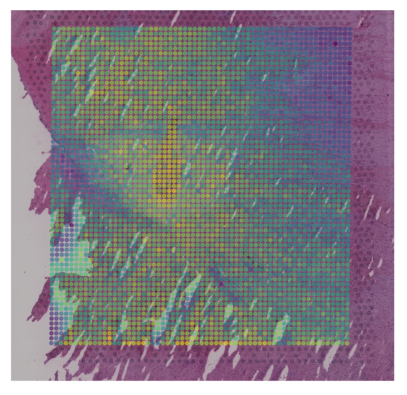

In [ ]:
# Transform MSI coordinates with MAGPIE landmarks
msi_raw = sc.read_h5ad(MSI_H5AD)
transformed_pixels, affine_matrix, landmark_inliers = apply_magpie_landmarks_to_msi(msi_raw,
    SECTION_DIR / "landmark/landmarks_noHE.csv", MSI_DIR / "MSI_metadata.csv")
msi_raw.write_h5ad(MSI_H5AD)
msi_intensities = pd.read_csv(MSI_DIR / "MSI_intensities.csv", index_col=0)
_ = plot_magpie_alignment_preview(RNA_DIR / "spatial/tissue_hires_image.png", transformed_pixels,
    msi_intensities, feature="674.28592")

## Spatial Annotation Integration

RNA barcodes are ordered according to `tissue_positions_list.csv` so that their spatial order remains stable. `region` and `dopamine` are read from the SMA annotations. `new_label` combines these annotations using the section-specific SMA rules, providing the reference label for spatial-domain evaluation and aligned visualization in Tutorial 5.2.

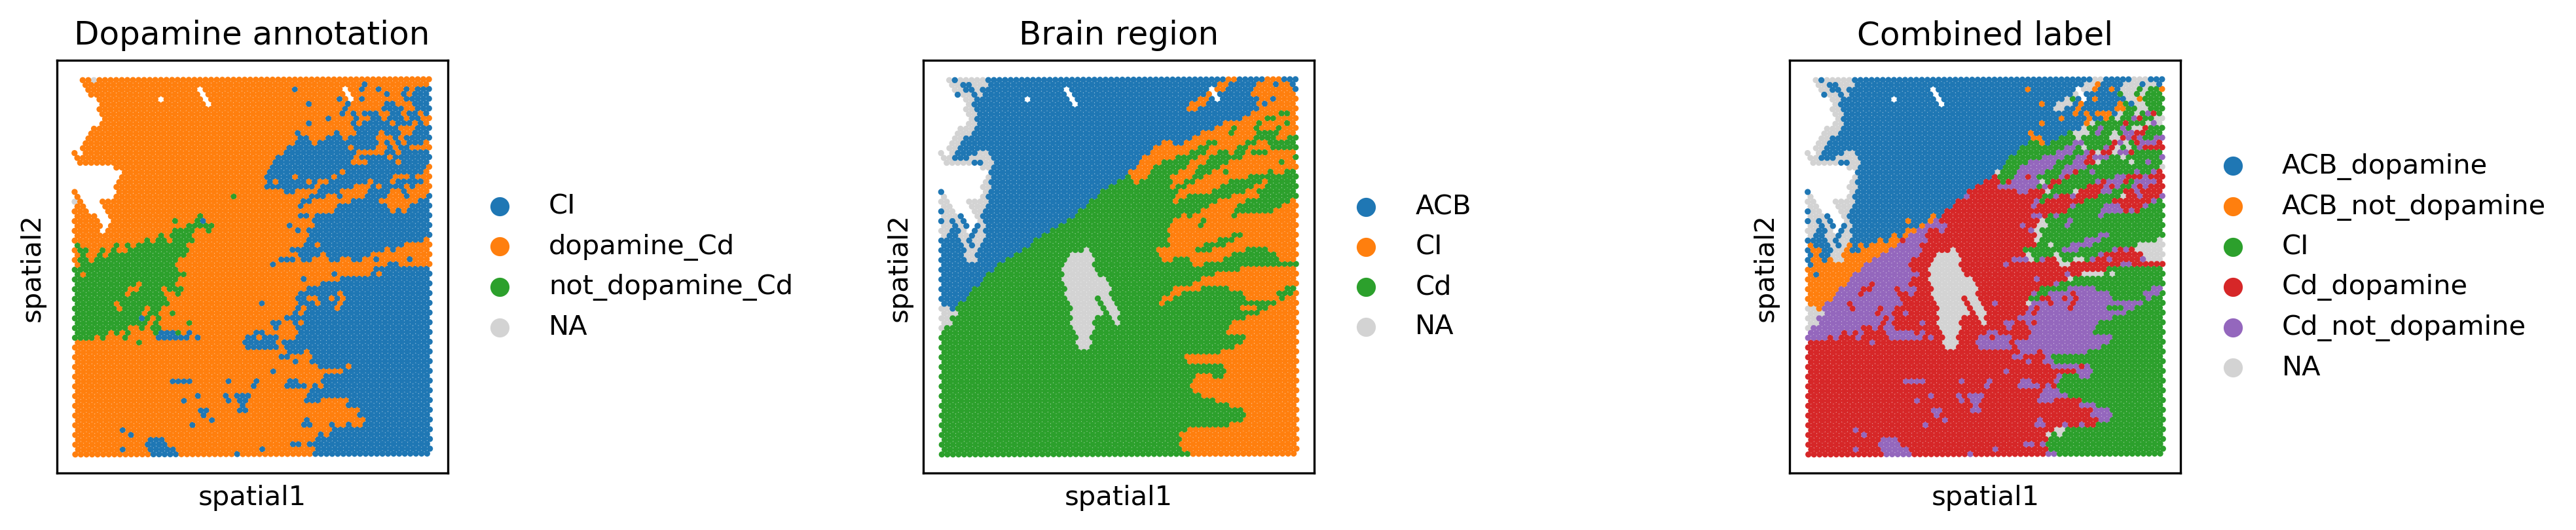

In [5]:
# Read RNA and attach SMA annotations
rna = prepare_sma_rna(RNA_10X_H5, TISSUE_POSITIONS_CSV, REGION_CSV, DOPAMINE_CSV, tag=TAG, swap_xy=True)
rna.write_h5ad(RNA_H5AD)
sma_label_table(rna).to_csv(LABEL_CSV)
rna_for_region_plot = rna.copy()
rna_for_region_plot.obs["region"] = rna_for_region_plot.obs["region"].replace("unk", pd.NA)
fig, axes = plt.subplots(1, 3, figsize=(13, 3), dpi=300)
for ax, adata, key, title in zip(axes, [rna, rna_for_region_plot, rna], ["dopamine", "region", "new_label"],
                                 ["Dopamine annotation", "Brain region", "Combined label"]):
    sc.pl.embedding(adata, basis="spatial", color=key, ax=ax, title=title, size=20, show=False,
                    legend_loc="right margin")
    ax.set_xlabel("spatial1")
    ax.set_ylabel("spatial2")
    ax.set_aspect("equal")
plt.subplots_adjust(left=0.05, right=0.98, bottom=0.15, top=0.85, wspace=0.35)
plt.show()

## RNA-MSI Pair Selection

MSI pixels are matched to their closest available RNA spots using a greedy one-to-one assignment. A match is retained only when its distance is at most `DISTANCE_THRESHOLD`. The registered MSI object uses RNA barcodes and RNA coordinates; the full object has exactly the RNA spot order. It assigns `missing="0"` and an all-zero MSI profile to locations without a retained pair or without a valid `new_label`.


{'matched_msi': 2567, 'unmatched_msi': 1463, 'rna_msi_missing': 2483}


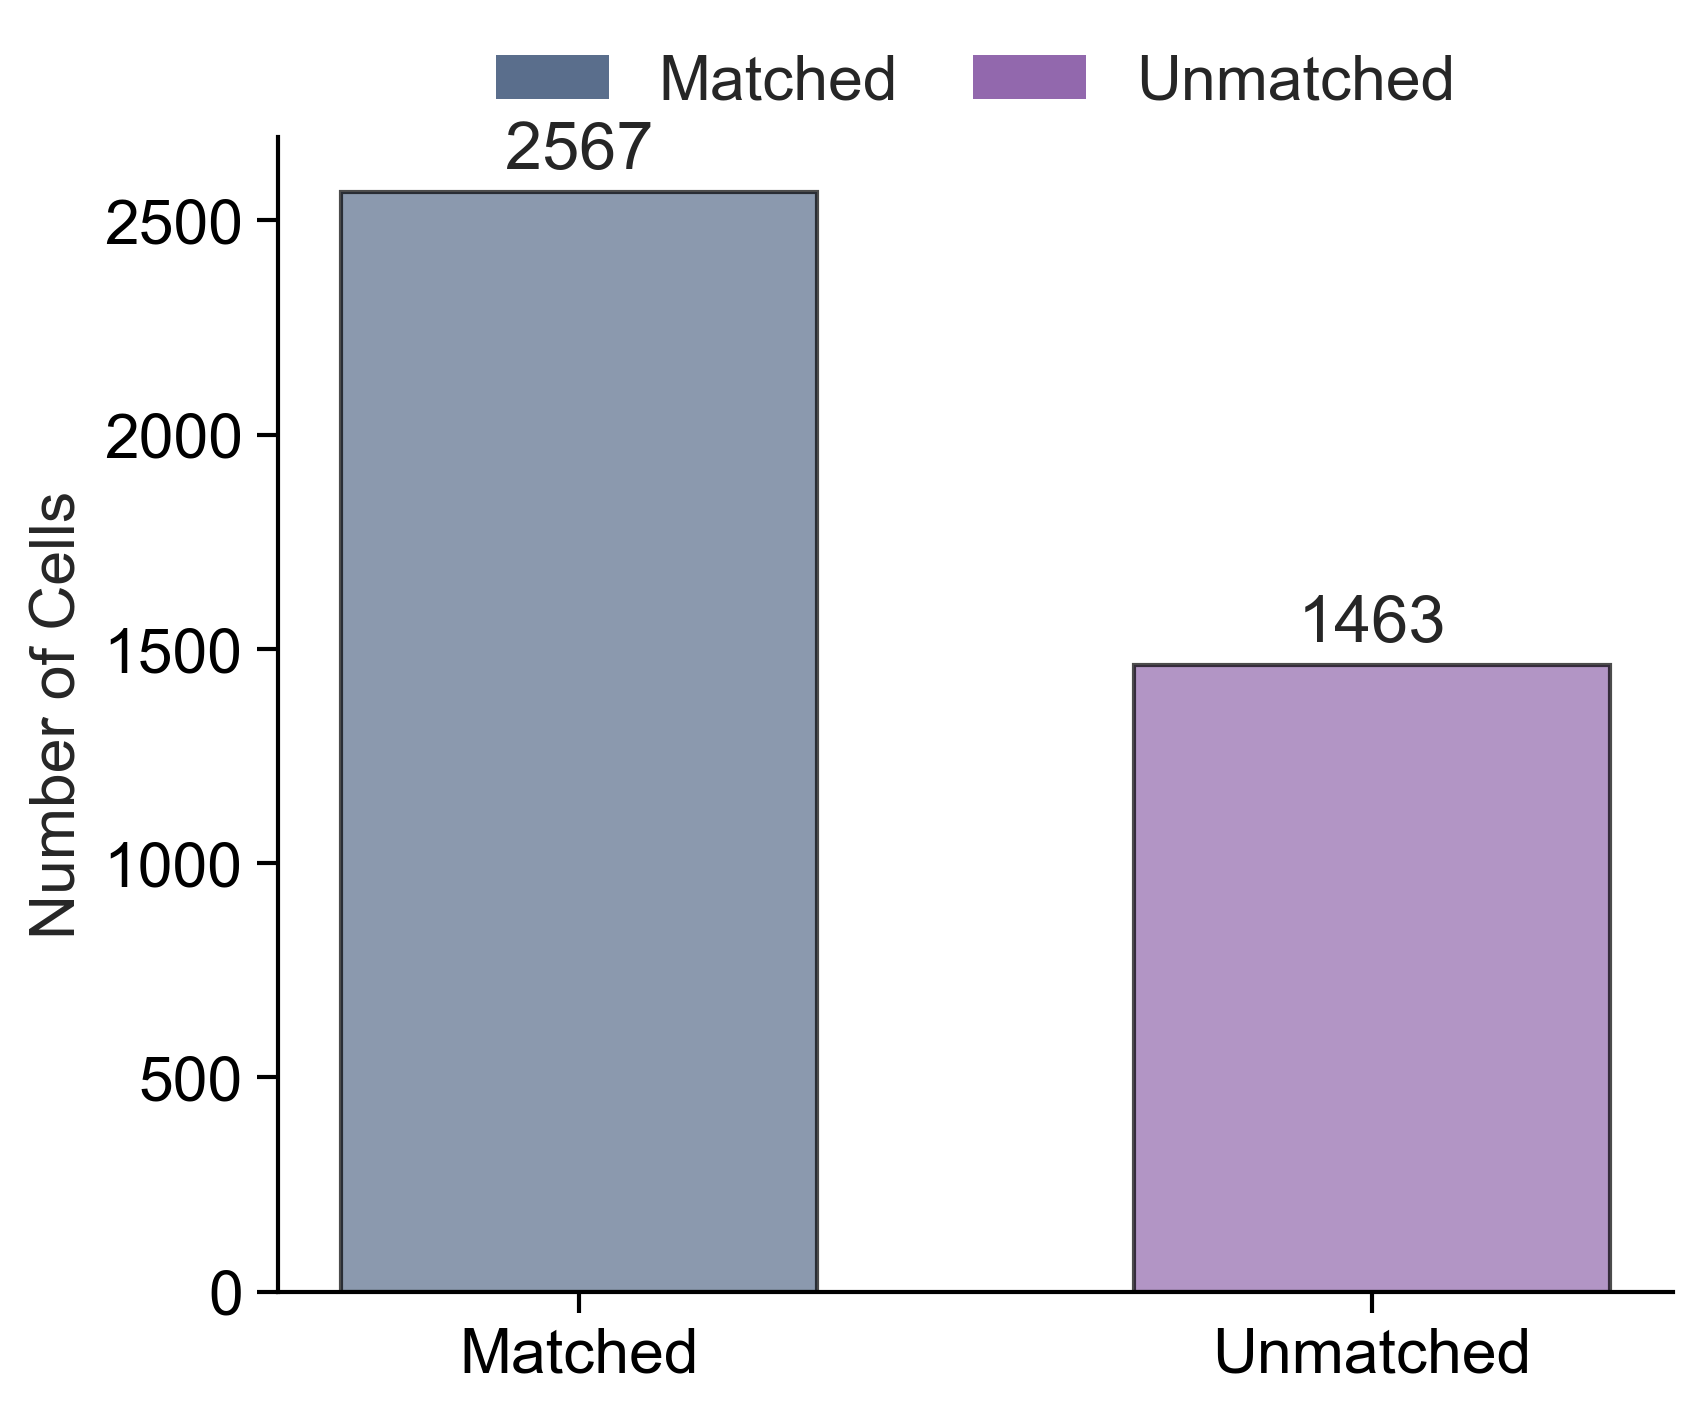

Total cells: 4030
Matched cells: 2567 (63.7%)
Unmatched cells: 1463 (36.3%)


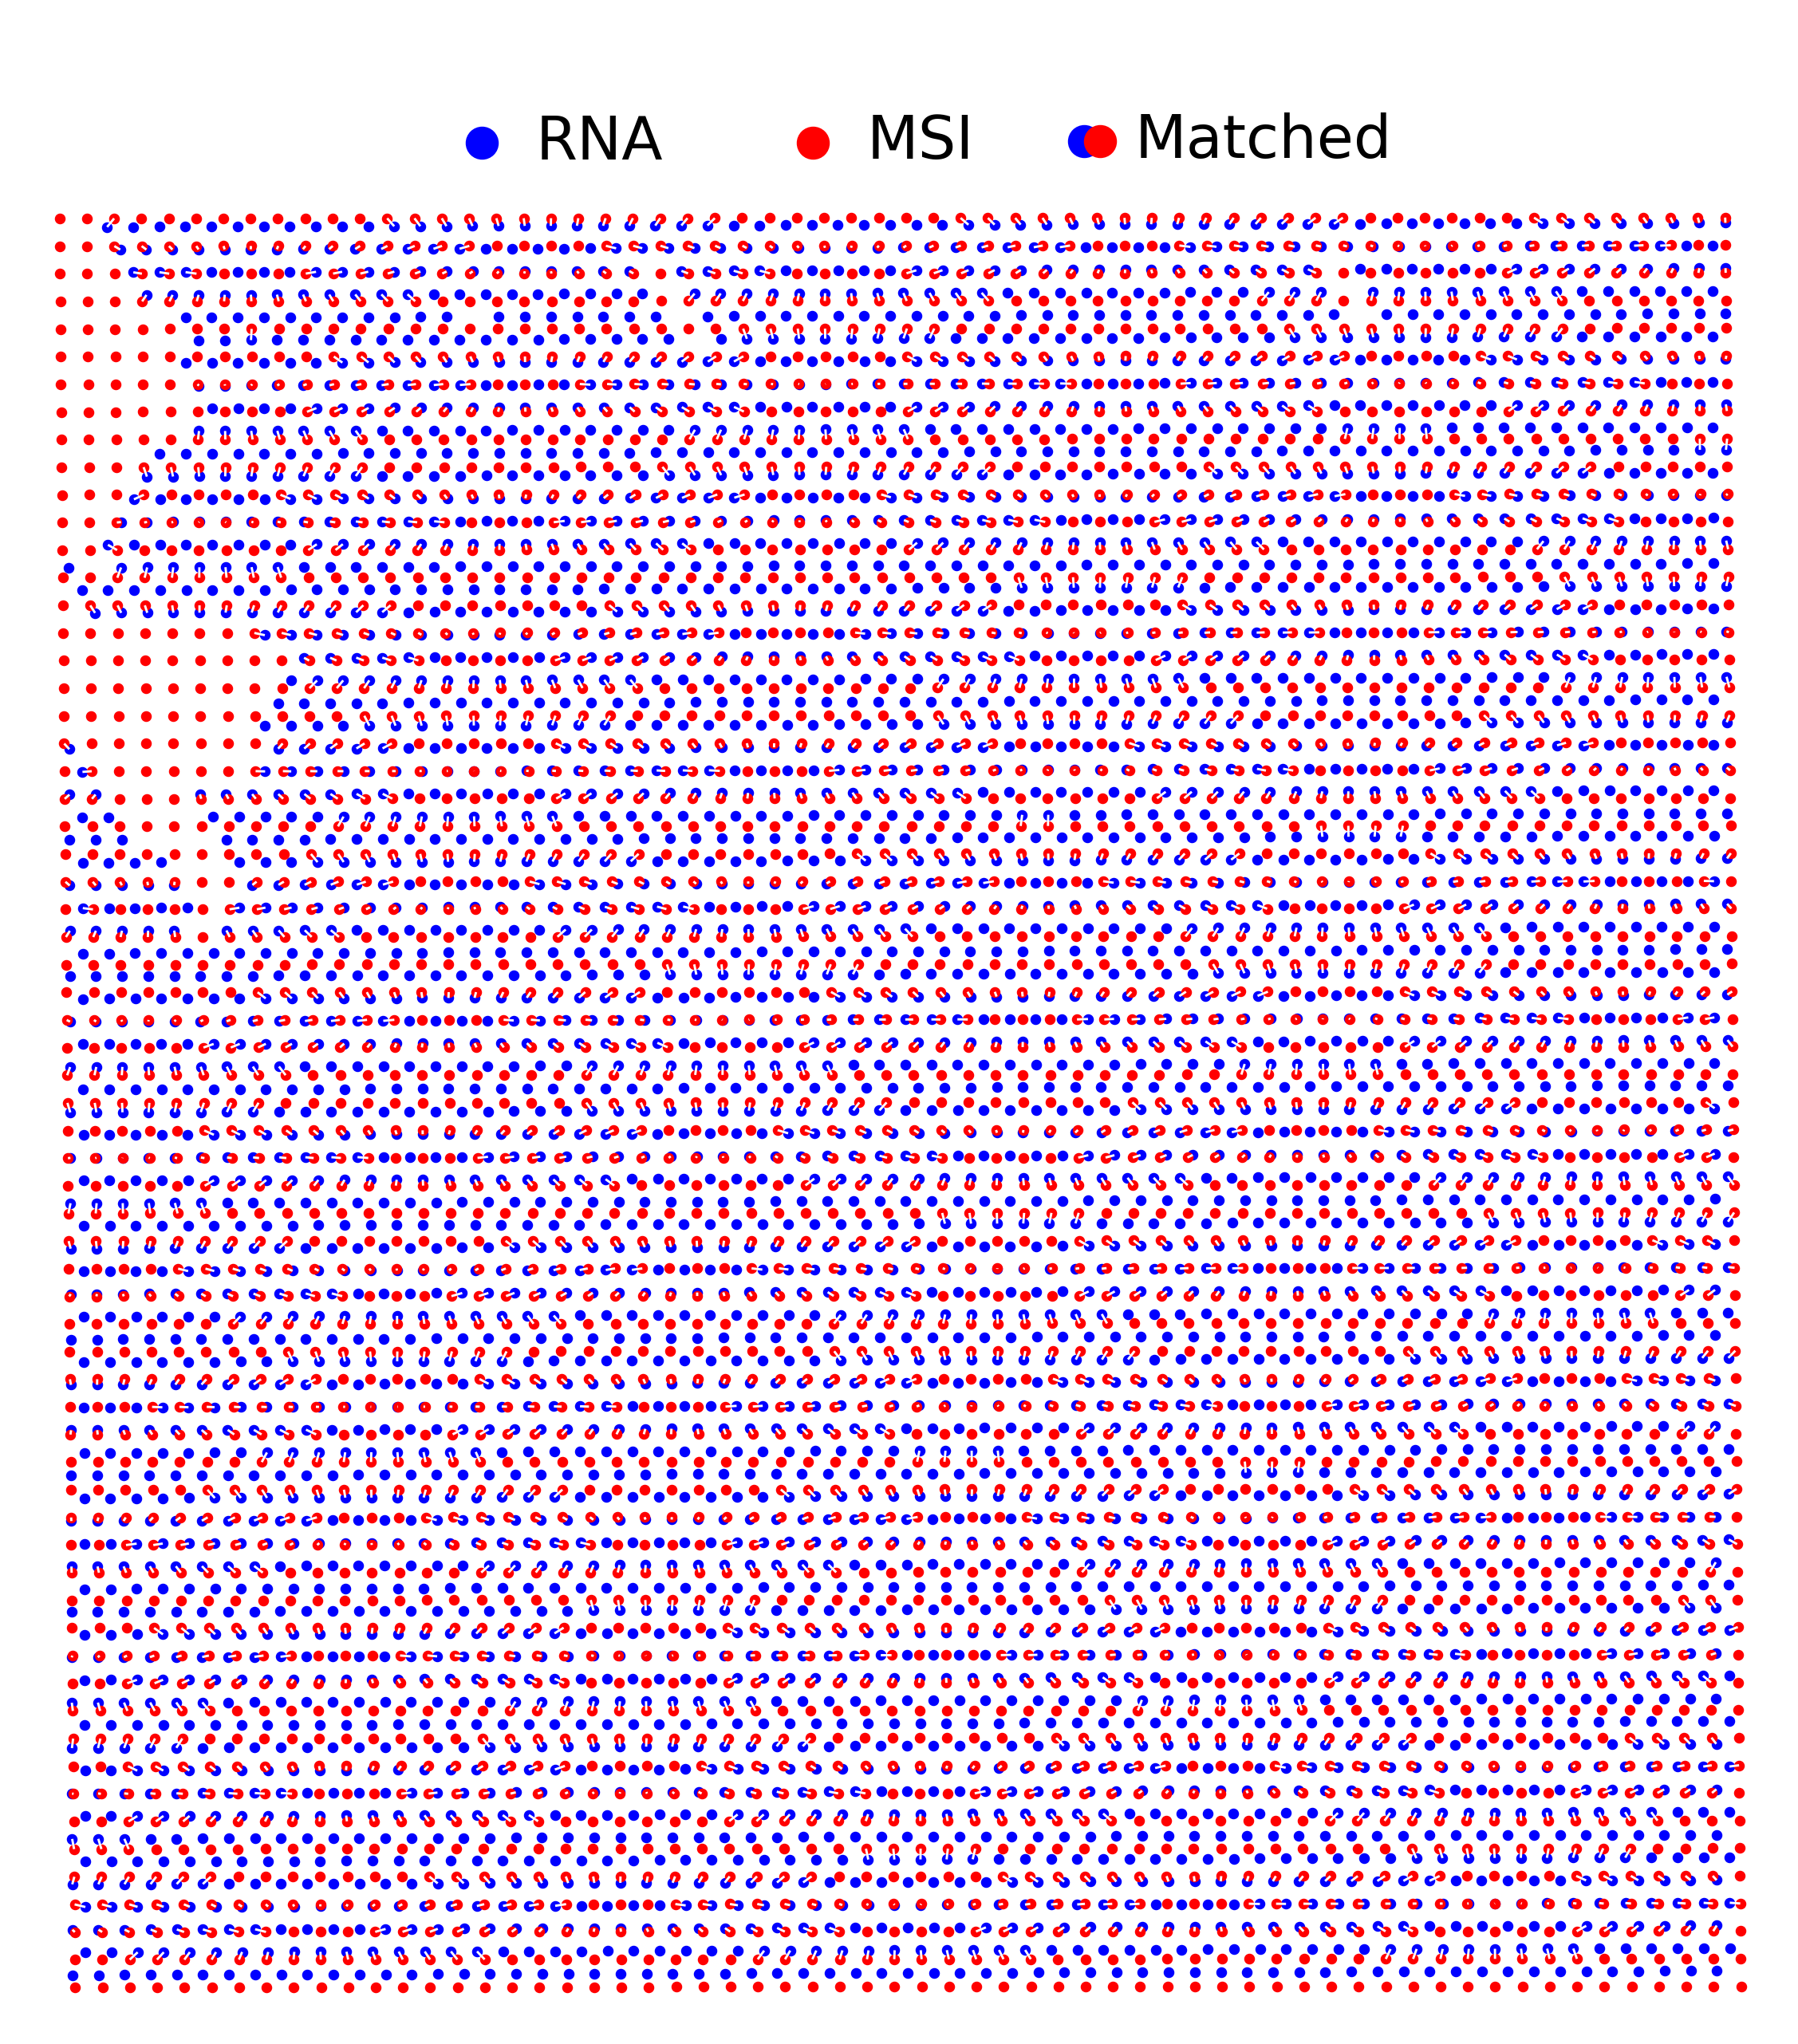

In [6]:
# Build registered and RNA-indexed MSI objects
rna = sc.read_h5ad(RNA_H5AD)
msi = sc.read_h5ad(MSI_H5AD)
mapping, matched_distance = greedy_spatial_matching(rna.obsm["spatial"], msi.obsm["spatial"],
    max_neighbors=5, distance_threshold=250)
spatial_mapping_table(rna, msi, mapping, matched_distance).to_csv(MAPPING_CSV, index=False)
aligned_msi = build_aligned_msi(rna, msi, mapping, matched_distance)
aligned_msi = aligned_msi[rna.obs_names[rna.obs_names.isin(aligned_msi.obs_names)]].copy()
full_msi = build_full_msi_with_missing(rna, aligned_msi, missing_key="missing", label_key="new_label")
write_sma_h5ad(full_msi, REGISTERED_MSI_H5AD)
print({"matched_msi": int((mapping >= 0).sum()), "unmatched_msi": int((mapping < 0).sum()),
       "rna_msi_missing": int((full_msi.obs["missing"].astype(str) == "0").sum())})

# 5. Inspect matching and the selected m/z feature
_ = plot_matching_summary_bar(mapping)
_ = plot_spatial_overlay(rna.obsm["spatial"], msi.obsm["spatial"], mapping=mapping,
                         show_match_lines=True)

## SMA Metabolite Annotation

The curated metabolites and their reference m/z values are reported in the SMA study's publicly available [Extended Data Fig. 9 metabolite-identification panel](https://www.nature.com/articles/s41587-023-01937-y/figures/11). Each entry is assigned to the nearest unused m/z feature only when its absolute mass error is at most 0.02. Original m/z values are retained in `var["mz_original"]`, while matched feature names become their paper metabolite names. This prepares both the registered and raw MSI objects for downstream PRISM analysis.


In [ ]:
# Annotate registered and raw MSI features with SMA paper metabolite names
registered_msi = sc.read_h5ad(REGISTERED_MSI_H5AD)
raw_msi = sc.read_h5ad(MSI_H5AD)
registered_msi_annotated, registered_match_table = annotate_sma_paper_metabolites(registered_msi,
    max_abs_error=0.02, rename_var_names=True)
raw_msi_annotated, raw_match_table = annotate_sma_paper_metabolites(raw_msi, max_abs_error=0.02,
    rename_var_names=True)
registered_msi_annotated.write_h5ad(REGISTERED_ANNOTATED_MSI_H5AD)
raw_msi_annotated.write_h5ad(RAW_ANNOTATED_MSI_H5AD)
display(registered_match_table)

,metabolite,target_mz,matched_mz,mz_error,ppm_error,matched
0,Dopamine,421.19,421.19136,0.00136,3.228947,True
1,Dopamine_DD,674.28,674.28050,0.00050,0.741532,True
2,GABA,371.18,371.17565,-0.00435,-11.719381,True
3,GABA_H2O,353.17,353.16818,-0.00182,-5.153326,True
4,Tocopherol,698.49,698.49196,0.00196,2.806053,True
5,Norepinephrine_DD,690.27,690.27454,0.00454,6.577136,True
6,DOPAC_DD,698.24,698.24258,0.00258,3.695005,True
7,3-MT,435.21,435.20692,-0.00308,-7.077043,True
8,Serotonin,444.21,444.20715,-0.00285,-6.415884,True
9,Taurine,393.13,393.12703,-0.00297,-7.554753,True


### Prepared outputs

The prepared section contains annotated RNA, MAGPIE-transformed MSI coordinates, the RNA-MSI mapping table, and registered and raw MSI objects required by the downstream PD analysis.
